In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

All the libraries are installed

In [2]:
df = pd.read_excel("World_development_mesurement.xlsx")
df.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


In [3]:
df.describe()

,Birth Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,Health Exp % GDP,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban
count,2585.000000,2.125000e+03,1718.000000,185.000000,1.785000e+03,2395.000000,1416.000000,2444.000000,2531.000000,1880.000000,2568.000000,2568.000000,2537.000000,2704.0,2484.000000,2484.000000,2484.000000,2.704000e+03,2678.000000
mean,0.022715,1.423071e+05,39.999418,94.875676,7.723684e+04,0.064170,302.068503,0.032813,0.239747,0.148103,71.159268,66.461838,0.578124,1.0,0.303051,0.623481,0.073465,3.145729e+07,0.562953
std,0.011338,6.159288e+05,57.318588,54.791906,2.599239e+05,0.026325,273.299686,0.029968,0.260132,0.171829,10.708262,9.390217,0.474647,0.0,0.106577,0.069660,0.049541,1.242894e+08,0.245897
min,0.007000,7.000000e+00,1.000000,1.000000,8.000000e+00,0.008000,12.000000,0.002000,0.000000,0.005000,39.000000,37.000000,0.000000,1.0,0.118000,0.474000,0.003000,1.887600e+04,0.082000
25%,0.013000,1.360000e+03,13.000000,48.000000,3.737000e+03,0.046000,156.000000,0.009000,0.000000,0.080000,64.000000,61.000000,0.100000,1.0,0.204750,0.559000,0.033000,8.783360e+05,0.356000
50%,0.020000,8.529000e+03,26.000000,94.000000,1.433800e+04,0.061000,239.000000,0.020000,0.100000,0.120000,75.000000,69.000000,0.500000,1.0,0.299500,0.642500,0.052000,5.800324e+06,0.560000
75%,0.031000,5.910800e+04,45.000000,142.000000,4.185200e+04,0.079000,344.750000,0.053000,0.400000,0.173000,79.000000,73.250000,0.900000,1.0,0.402000,0.676000,0.112000,2.014089e+07,0.765000
max,0.053000,8.286892e+06,694.000000,189.000000,2.727728e+06,0.225000,2600.000000,0.141000,1.000000,4.965000,87.000000,88.000000,2.900000,1.0,0.500000,0.858000,0.244000,1.350695e+09,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

In [5]:
df.isnull().sum()

Birth Rate                 119
Business Tax Rate         1281
CO2 Emissions              579
Country                      0
Days to Start Business     986
Ease of Business          2519
Energy Usage               919
GDP                        210
Health Exp % GDP           309
Health Exp/Capita          309
Hours to do Tax           1288
Infant Mortality Rate      260
Internet Usage             173
Lending Interest           824
Life Expectancy Female     136
Life Expectancy Male       136
Mobile Phone Usage         167
Number of Records            0
Population 0-14            220
Population 15-64           220
Population 65+             220
Population Total             0
Population Urban            26
Tourism Inbound            368
Tourism Outbound           471
dtype: int64

In [6]:
df.drop(['Business Tax Rate', 'Ease of Business', 'Hours to do Tax'], axis=1, inplace=True)

Since there are columns which exceeds null values more than 40% they are dropped from the dataset

In [7]:
cols = ['GDP', 'Health Exp/Capita', 'Tourism Inbound','Tourism Outbound'] 

for col in cols:
    df[col] = df[col].replace({'\$': '', '%': '', ',': ''}, regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

Special symbols like $ % are removed from the data set and they are converted into numeric columns

In [8]:
num_col = df.select_dtypes(include=['number'])
num_col = num_col.fillna(num_col.median())

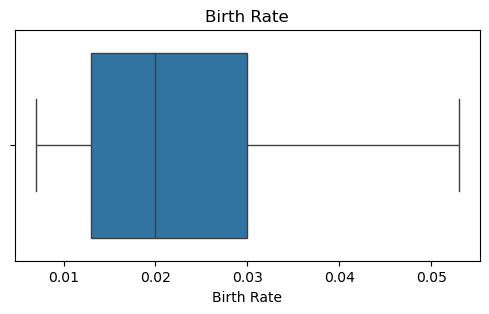

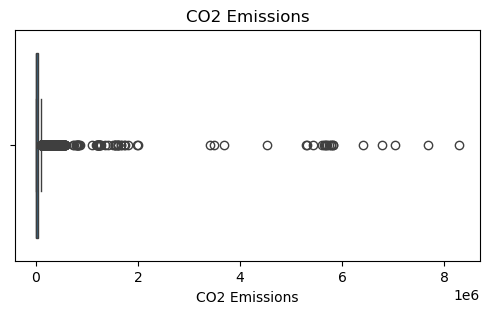

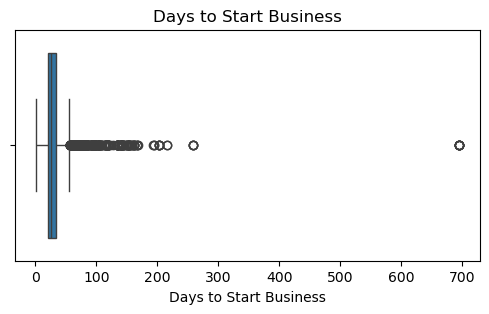

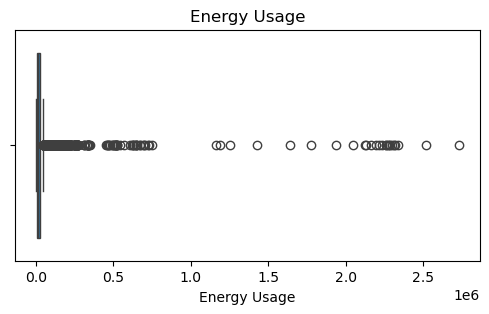

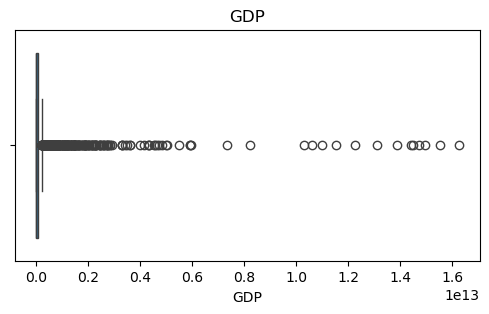

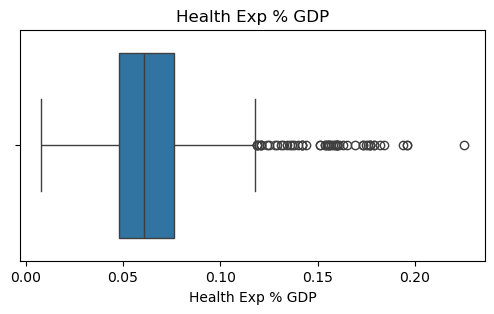

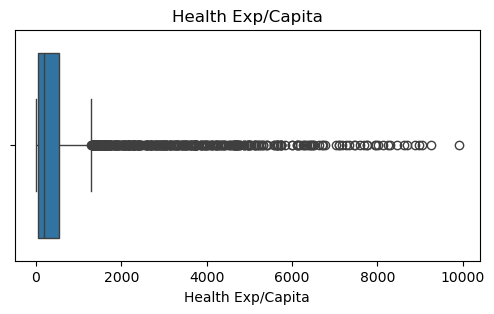

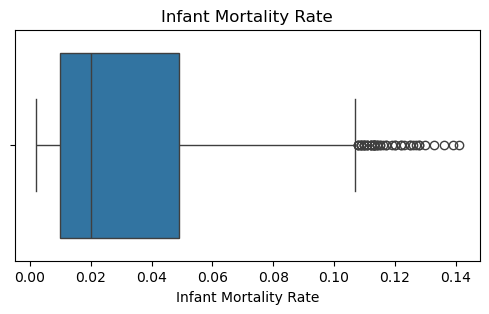

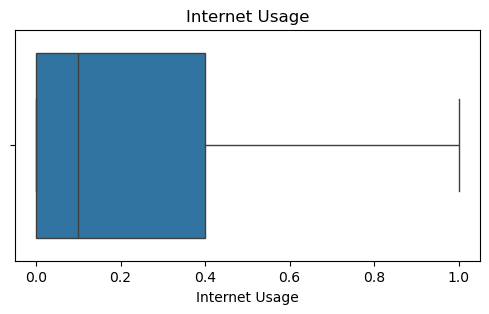

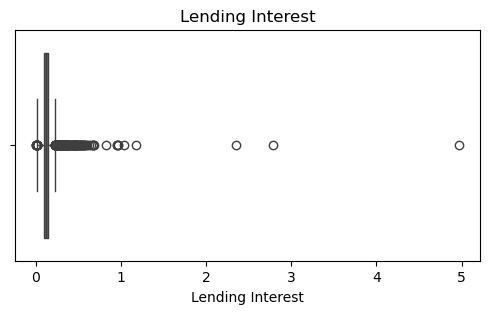

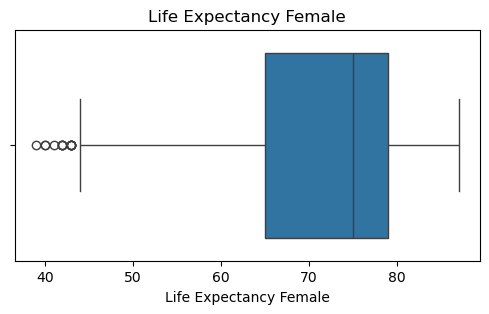

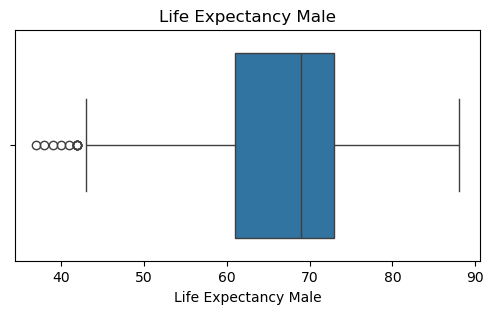

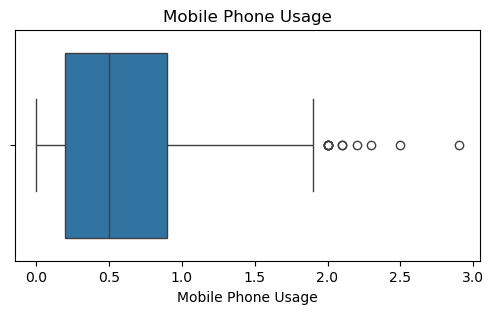

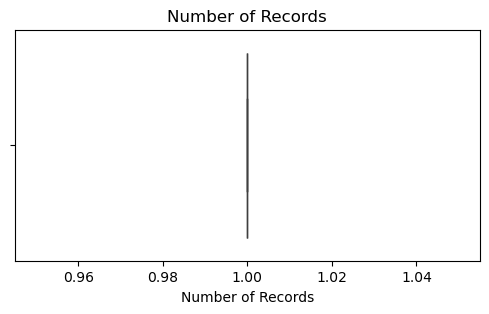

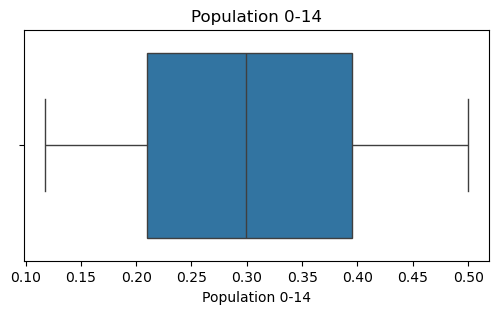

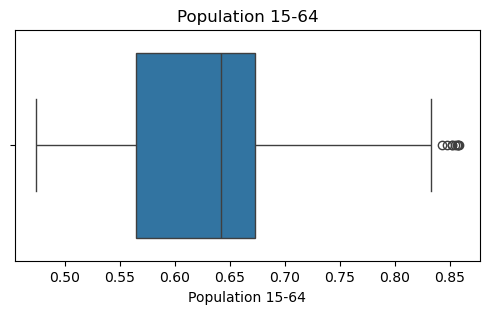

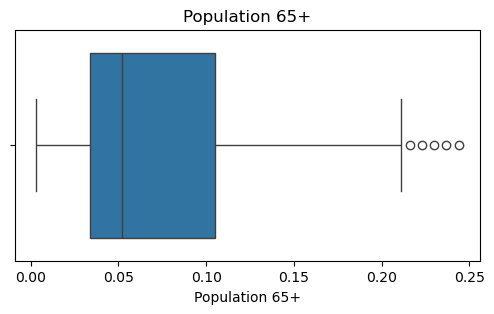

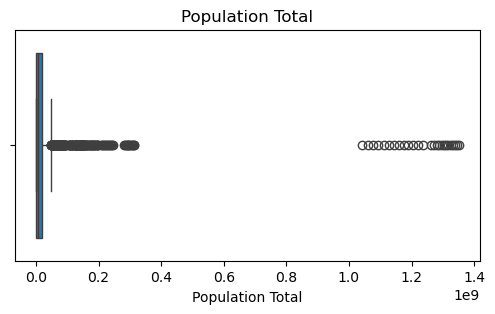

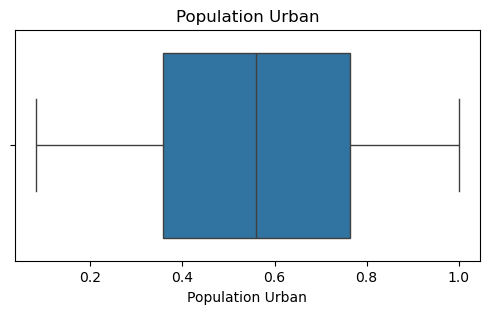

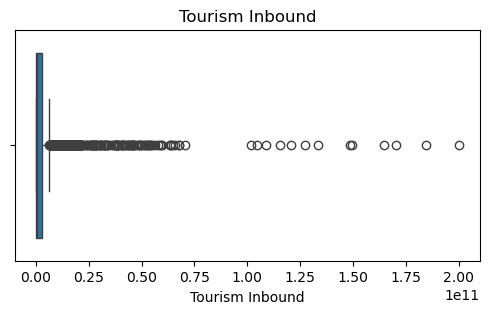

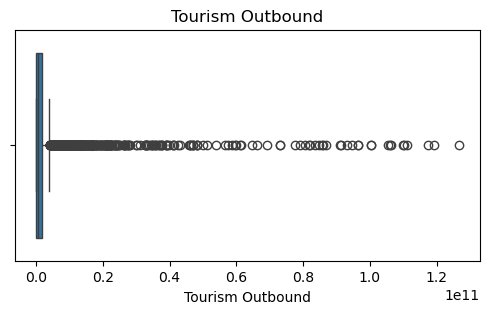

In [9]:
for col in num_col.columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=num_col[col])
    plt.title(col)
    plt.show()

Even though outliers are present in the dataset, they are retained because they represent real-world variations among countries. In the context of world development data, extreme values are meaningful (e.g., very high GDP or very low income countries) and contribute to better cluster differentiation. Removing them may lead to loss of important information.

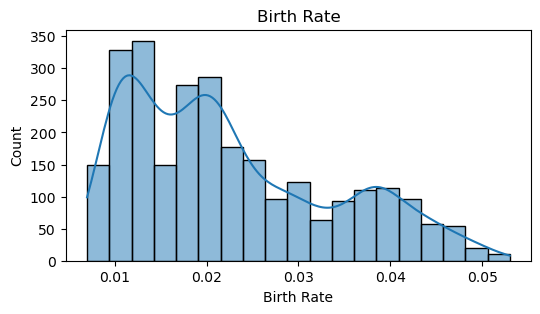

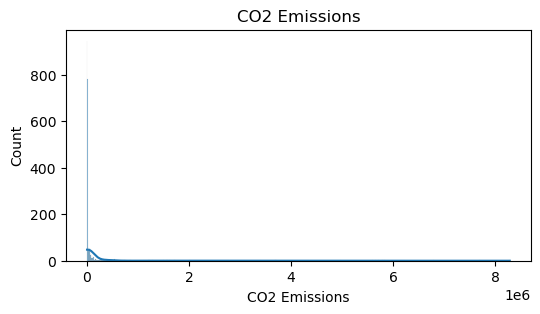

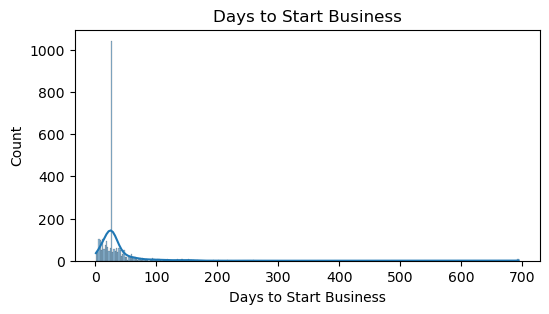

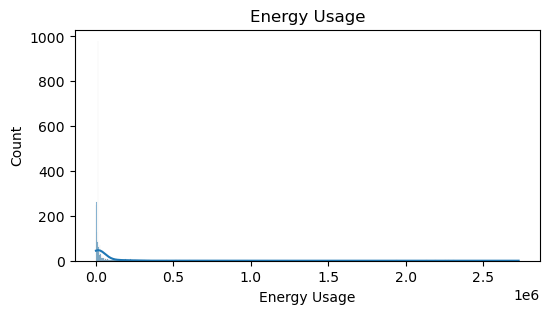

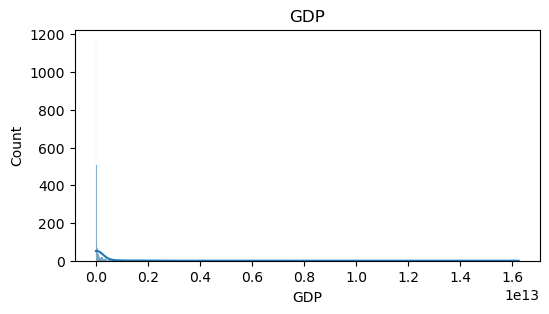

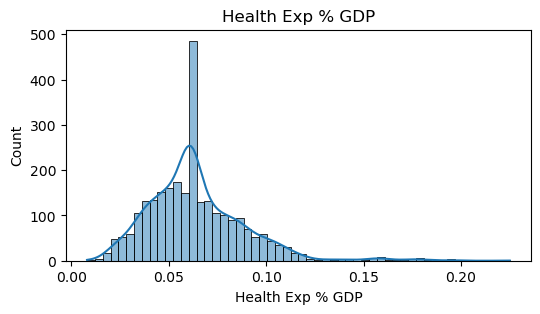

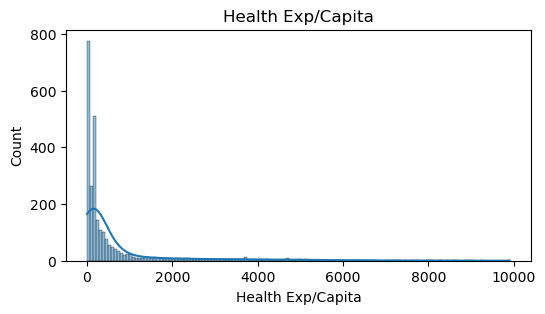

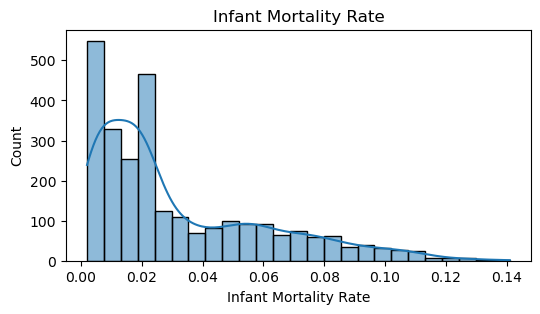

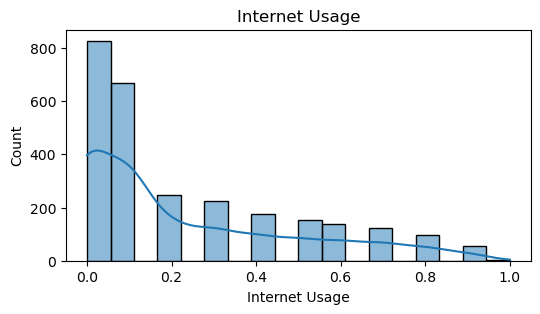

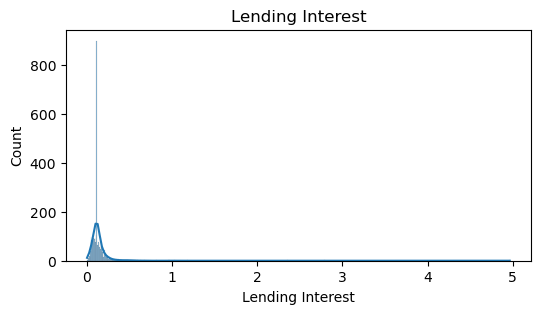

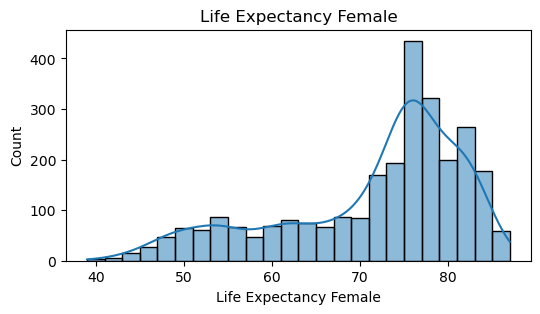

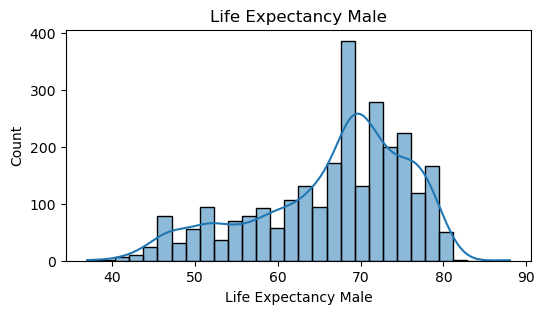

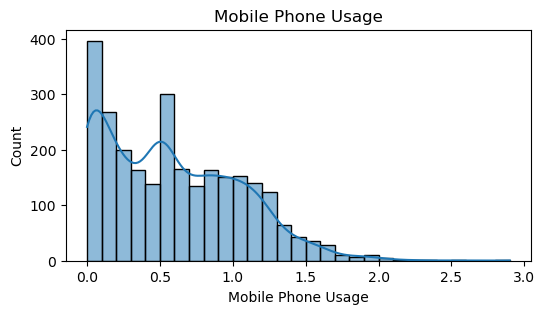

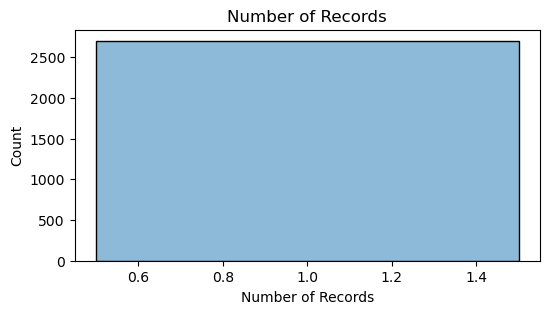

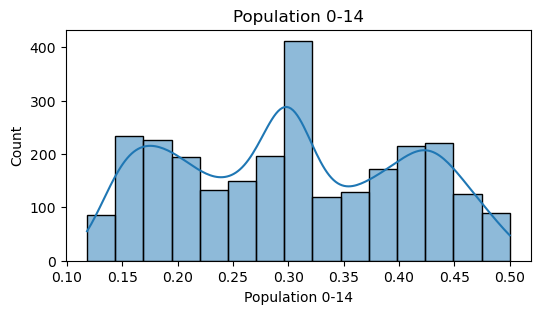

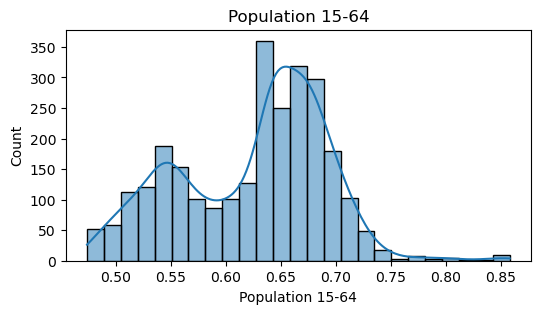

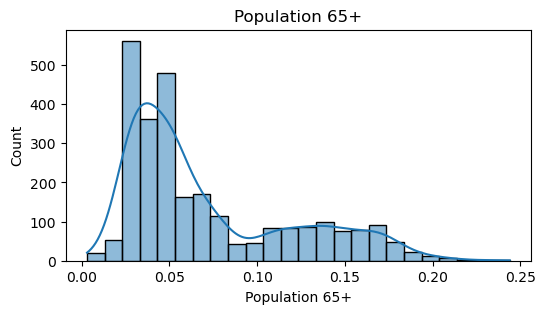

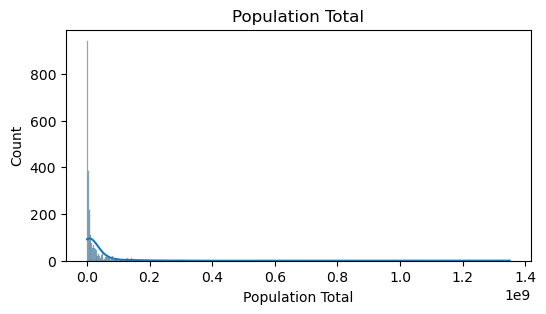

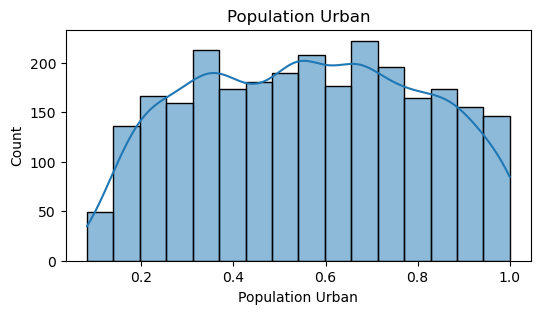

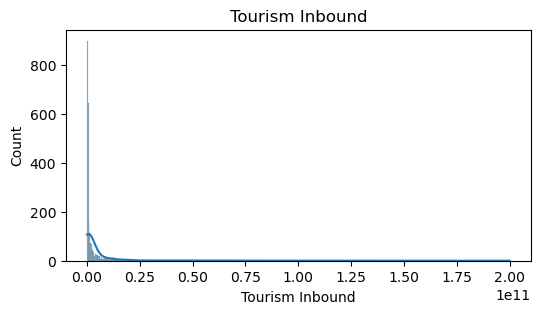

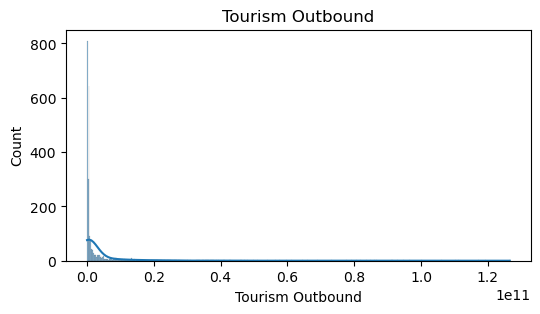

In [10]:
for col in num_col.columns:
    plt.figure(figsize=(6,3))
    sns.histplot(num_col[col], kde=True)
    plt.title(col)
    plt.show()

Some features showed skewness due to economic inequality across countries, which is expected in world development data.

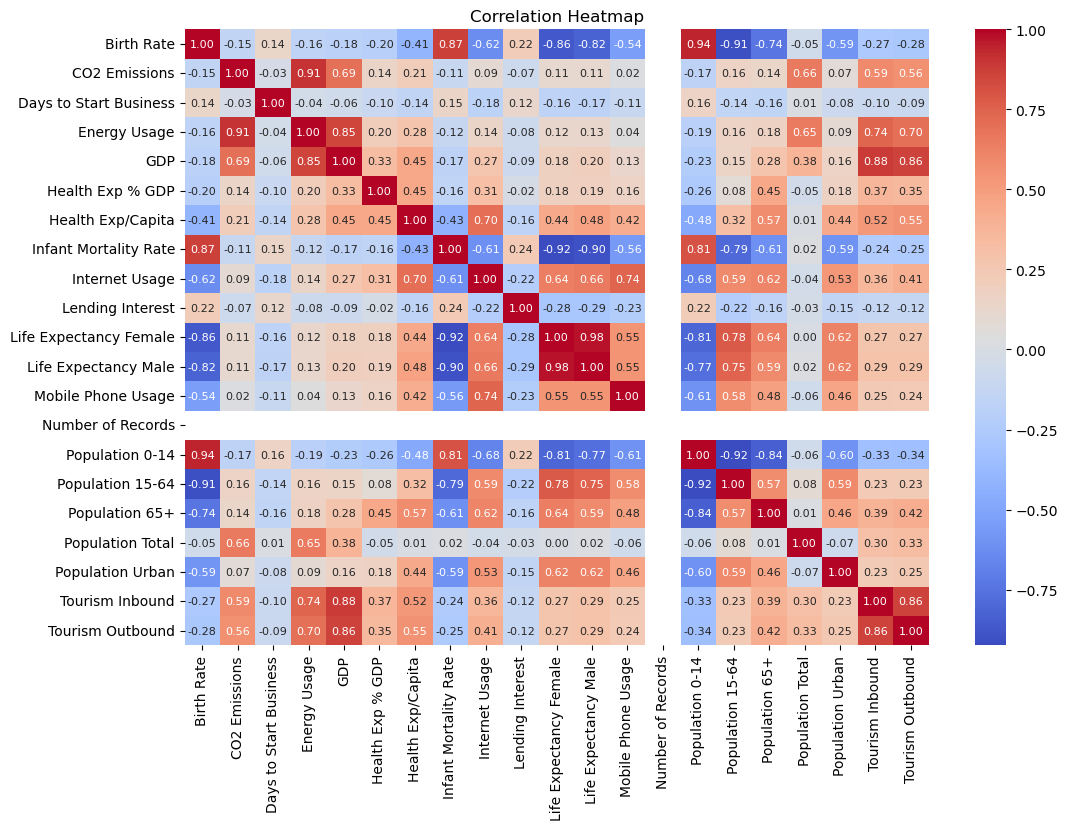

In [11]:
corr = num_col.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f",annot_kws={"size":8})
plt.title("Correlation Heatmap")
plt.show()

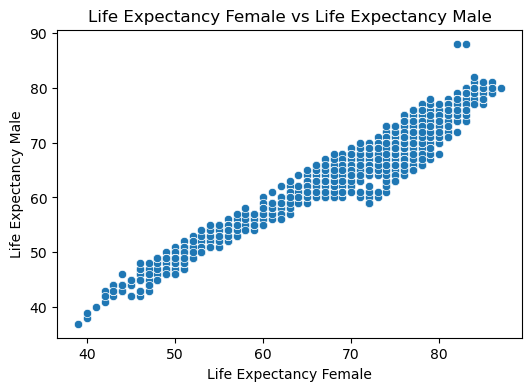

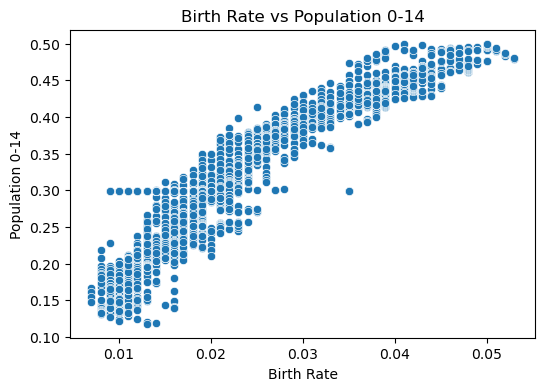

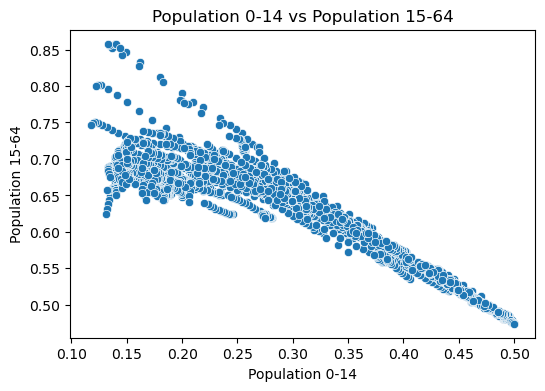

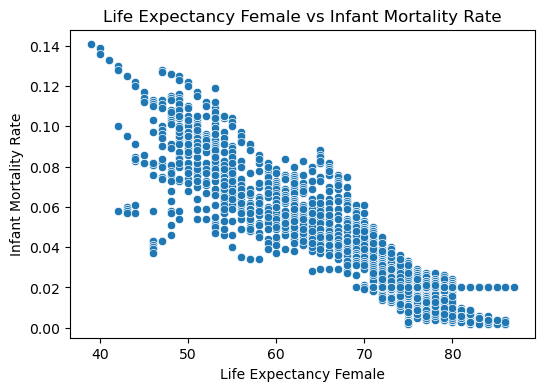

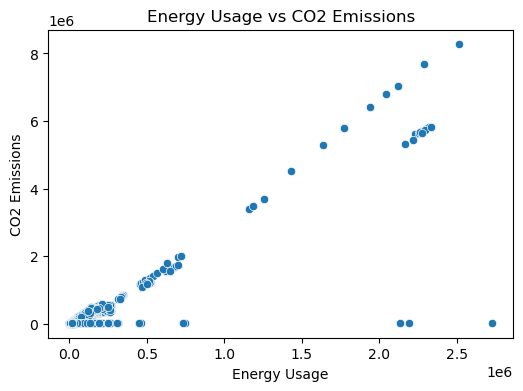

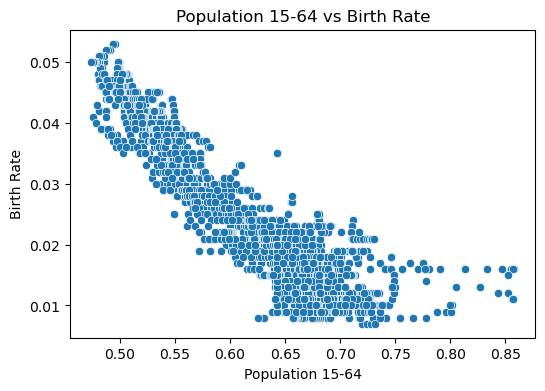

In [12]:
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1].drop_duplicates()

top_pairs = corr_pairs.head(6).index.tolist()

for x_col, y_col in top_pairs:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=num_col[x_col], y=num_col[y_col])
    plt.title(f"{x_col} vs {y_col}")
    plt.show()

In [13]:
#standardization
scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_col)

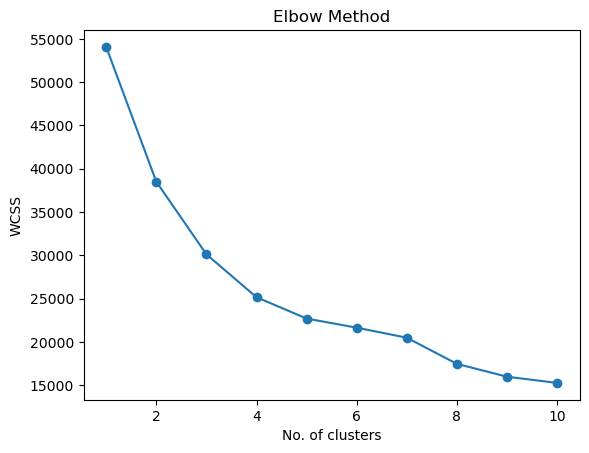

In [14]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("No. of clusters")
plt.ylabel("WCSS")
plt.show()

In [15]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)

kmeans_score = silhouette_score(scaled_data, kmeans_labels)

if len(set(dbscan_labels)) > 1:
    dbscan_score = silhouette_score(scaled_data, dbscan_labels)
else:
    dbscan_score = -1

print("KMeans:", kmeans_score)
print("DBSCAN:", dbscan_score)

KMeans: 0.3404841200289595
DBSCAN: -0.17984114209282895


In [16]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

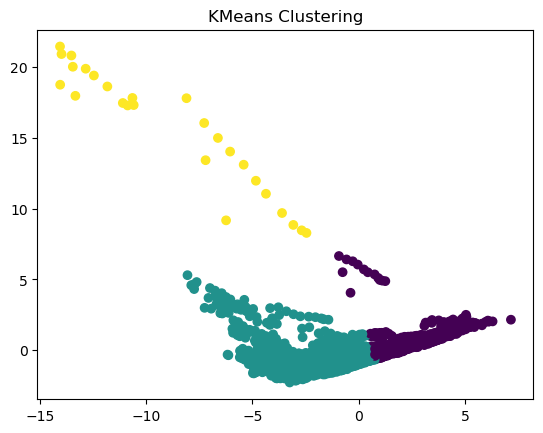

In [17]:
plt.scatter(pca_data[:,0], pca_data[:,1], c=kmeans_labels)
plt.title("KMeans Clustering")
plt.show()

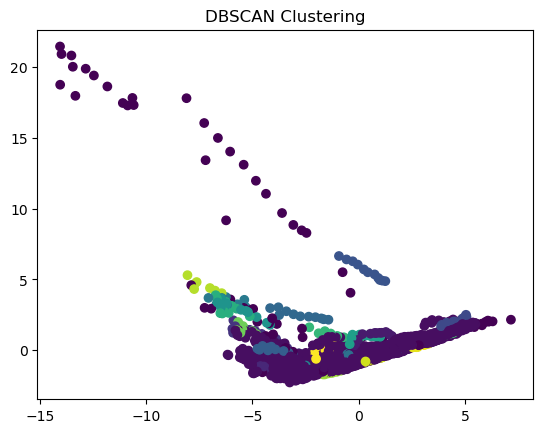

In [18]:
plt.scatter(pca_data[:,0], pca_data[:,1], c=dbscan_labels)
plt.title("DBSCAN Clustering")
plt.show()

In [19]:
df['Cluster'] = kmeans_labels
df.groupby('Cluster').mean(numeric_only=True)

,Birth Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Lending Interest,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.033912,3.898056e+04,54.103399,2.856797e+04,3.336533e+10,0.057582,76.353575,0.059991,0.033728,0.199422,...,57.840114,0.230207,1.0,0.407928,0.556622,0.035444,3.370948e+07,0.368570,6.026759e+08,5.217922e+08
1,0.015003,1.187993e+05,30.307460,6.000408e+04,2.786797e+11,0.068380,1297.548961,0.012081,0.376861,0.115556,...,72.467340,0.813818,1.0,0.225739,0.672644,0.101617,1.760069e+07,0.690844,6.166321e+09,6.075586e+09
2,0.013038,5.665634e+06,22.850000,2.053692e+06,8.461556e+12,0.104577,3549.730769,0.013192,0.411538,0.056154,...,73.961538,0.553846,1.0,0.205308,0.692500,0.102154,8.038033e+08,0.619692,8.808477e+10,7.074662e+10


The dataset was cleaned by removing symbols, handling missing values, and dropping high-null columns. Exploratory data analysis was performed using boxplots, histograms, scatter plots, and correlation heatmaps. The data was standardized before applying clustering algorithms. KMeans and DBSCAN were implemented, and their performance was evaluated using silhouette score. KMeans performed better and was selected as the final model. PCA was used to visualize the clusters, and cluster-wise analysis provided meaningful insights into country groupings.